<a href="https://colab.research.google.com/github/vladgap/Various/blob/main/2D_3D_3D%2B_function_approximation_no_scale_100326.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [83]:
class NN:
    """Creates a two layer neuron network: the hidden layer and the output layer.
       The output layer may be multiple.
       The activation functions of the layers may be set.

       X and T are numpy column vectors or set of column vectors as numpy matrices.
       If the data is pandas dataframe, it should be turned to numpy:
          X=np.array(DataFrame[[x0,x1,...]])
          T=np.array(DataFrame[[t0,...]])
       The same for confidences.

       Attributes:
          layers: A list of layers. [2,3,1] -- 2 inputs, 3 neurons in hidden layer, 1 neuron in output layer
          hidden_activation: Activation function of the hidden layer. 'linear' (by default), 'sigmoid', 'prelu'.
          output_activation: Activation function of the output layer. 'linear' (by default) for regression, 'softmax' for classification.
          Wh, bh, Wo, bo: Matrices of weights.
          JWh, Jbh, JWo, Jbo: Matrices of weight Jacobian.
          Wh_history, bh_history, Wo_history, bo_history: 3D numpy arrays with histories of weights."""

    def __init__(self, layers, hidden_activation='linear', output_activation='linear'):
        """Return a new MLP object with the specified parameters.
           layers: A list of layers. [2,3,1] -- 2 inputs, 3 neurons in hidden layer, 1 neuron in output layer
           hidden_activation: Activation function of the hidden layer. 'linear' (by default), 'sigmoid', 'prelu'.
           output_activation: Activation function of the output layer. 'linear' (by default) for regression, 'softmax' for classification."""
        self.layers = layers
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.imported = False  # before weights import

    def sigmoid(self, x):
        """Sigmoid activation function."""
        return 1. / (1. + np.exp(-x))

    def sigmoid_deriv(self, x):
        """Sigmoid derivative function."""
        return x * (1 - x)

    def PReLU(self, x):
        """Parametric ReLU activation function.
           Parameter = 0.001"""
        np.copyto(x, np.maximum(0.001 * x, x))
        return x

    def PReLU_deriv(self, x):
        """Parametric ReLU derivative function:
           Matrix with ones for positives and 0.001s for negatives."""
        y = np.ones_like(x)
        y[x < 0] = 0.001
        return y

    def softmax(self, x):
        """Softmax activation function"""
        return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

    def hidden_activations(self, X):
        """Compute the hidden activations H.
           self.hidden_activation may be 'linear' (default), 'sigmoid' or 'prelu'."""
        Zh = (X @ self.Wh) + self.bh
        if self.hidden_activation == 'sigmoid':
            return self.sigmoid(Zh)
        elif self.hidden_activation == 'prelu':
            return self.PReLU(Zh)
        return Zh  # default (linear) activation

    def output_activations(self, H):
        """Compute the output Y.
           self.output_activation may be 'linear' (default) or 'softmax'."""
        Zo = (H @ self.Wo) + self.bo
        if self.output_activation == 'softmax':
            return self.softmax(Zo)
        if self.output_activation == 'linear':
            return Zo
        return Zo  # default

    def __run(self, X):
        """Runs the input X vectors of input layer, returns the Y vectors of output layer."""
        return self.output_activations(self.hidden_activations(X))

    def loss(self, Y, T, confidences=None):
        """Loss function.
           Regression: MSE (output_activation -- 'linear').
           Classification: cross-entropy (output_activation -- 'softmax')."""
        SE = (Y - T) ** 2  # MSE
        abs_err = np.abs(Y - T)  # ABS
        confidences = np.ones_like(T) if confidences is None else confidences
        confidences = np.minimum(confidences, 1e4)  # avoid confidences=inf (variance=0)
        weighted_SE = SE * confidences
        MSE = weighted_SE.sum() / Y.shape[0]
        if self.output_activation == 'linear':
            return MSE
        if self.output_activation == 'softmax':
            return - (T * np.log(Y)).sum()  # softmax layer with corresponding cross-entropy loss function
        return MSE  # default

    def error_output(self, Y, T):
        """Error function at the output"""
        return (Y - T) * self.confidences  # same for softmax and MSE

    def gradient_weight_out(self, H, Eo):
        """Gradients for the weight parameters at the output layer"""
        return H.T @ Eo

    def gradient_bias_out(self, Eo):
        """Gradients for the bias parameters at the output layer"""
        return np.sum(Eo, axis=0, keepdims=True)

    def error_hidden(self, H, Eo):
        """Error at the hidden layer.
        H * (1-H) * (E . Wo^T) for sigmoid
        [1 for pos, 0.001 for neg] * (E . Wo^T) for PReLU
        (E . Wo^T) for linear (default)."""
        if self.hidden_activation == 'sigmoid':
            return np.multiply(self.sigmoid_deriv(H), (Eo @ self.Wo.T))
        if self.hidden_activation == 'prelu':
            return np.multiply(self.PReLU_deriv(H), (Eo @ self.Wo.T))
        if self.hidden_activation == 'linear':
            return (Eo @ self.Wo.T)
        return (Eo @ self.Wo.T)  # default

    def gradient_weight_hidden(self, X, Eh):
        """Gradient for the weight parameters at the hidden layer"""
        return X.T @ Eh

    def gradient_bias_hidden(self, Eh):
        """Gradient for the bias parameters at the output layer"""
        return np.sum(Eh, axis=0, keepdims=True)

    def generate_weights(self, init_var=0.1):
        # Initialize hidden layer parameters
        bh = np.random.randn(1, self.layers[1]) * init_var
        Wh = np.random.randn(self.layers[0], self.layers[1]) * init_var
        # Initialize output layer parameters
        bo = np.random.randn(1, self.layers[2]) * init_var
        Wo = np.random.randn(self.layers[1], self.layers[2]) * init_var
        return Wh, bh, Wo, bo

    def get_gradients(self, X, T):
        """Update the network parameters over 1 iteration."""
        # Compute the output of the network
        H = self.hidden_activations(X)
        Y = self.output_activations(H)
        # Compute the gradients of the output layer
        Eo = self.error_output(Y, T)
        self.JWo = self.gradient_weight_out(H, Eo)
        self.Jbo = self.gradient_bias_out(Eo)
        # Compute the gradients of the hidden layer
        Eh = self.error_hidden(H, Eo)
        self.JWh = self.gradient_weight_hidden(X, Eh)
        self.Jbh = self.gradient_bias_hidden(Eh)

    def update_momentum(self, X, T, Ms, lr_decay, momentum_term):
        self.get_gradients(X, T)
        Js = [self.JWh, self.Jbh, self.JWo, self.Jbo]
        return [momentum_term * M - lr_decay * J
                for M, J in zip(Ms, Js)]

    def update_weights(self, Ms):
        Ws = [self.Wh, self.bh, self.Wo, self.bo]
        return [P + M for P, M in zip(Ws, Ms)]

    def fit(self, X, T, epochs, confidences=None, X_valid=[], T_valid=[], learning_rate=0.01, learning_rate_decay=0, momentum_term=0.9,
            init_var=0.1, repeat=False):
        """Run backpropagation:
              1. Initilizes weights matrices (if repeat is False)
              2. Creates list of losses and calculates initial loss by rinning self.loss() for train data and validation data (if present)
              3. Creates lists of weight matrices and puts initial matrices
              4. Starts epoch iterations for weights and loss update
                a. Calculates learning rate decay:
                   lr_decay = learning_rate / (1 + learning_rate_decay * epoch)
                   learning_rate_decay = 0 in case of constant learning rate
                b. Runs update_momentum() function, which calls get_gradients() function.
                   get_gradients() calculates H, Y, Eo, Eh and returns weights' Jacobians: self.JWh, self.Jbh, self.JWo, self.Jbo
                   update_momentum() returns list of momentums and replaces the previous ones
                c. Runs update_weights() which returns new weight matrices and replaces the previous ones
                d. Calculates loss and addes to the list of losses for train data and validation data (if present)
                e. New weight matrices are added to their lists
              5. Lists of weight matrices are turned to .self numpy arrays for better slicing option

           epochs: int number of epochs
           X and T are numpy column vectors or set of column vectors as numpy matrices.
           If the data is pandas dataframe, it should be turned to numpy:
              X=np.array(DataFrame[[x0,x1,...]])
              T=np.array(DataFrame[[t0,...]])
           confidences: 1/variances. None by default. If present, the function calculates the confidence interval of the loss.
           learning_rate: learning rate, 0.01 by default
           learning_rate_decay: learning rate decay, 0 by default, integer or float
           momentum_term: momentum term, 0.9 by default, 0 for simple gradiend descent
           init_var: initial variance of generated weights, multiplies np.random.randn(), 0.1 by default
           repeat: False -- new weights are generated,
                   True -- old weights are used from previous fit() or import_weights()

           The results are:
           self.loss_list -- list of floats
           self.valid_loss_list -- list of floats (if validation data is present)
           """
        # Calculate scale data: mean and std
        scaler_X = preprocessing.StandardScaler().fit(X)
        scaler_T = preprocessing.StandardScaler().fit(T)
        self.scaler_X, self.scaler_T = scaler_X, scaler_T
        self.mean_X, self.std_X = scaler_X.mean_, scaler_X.scale_
        self.mean_T, self.std_T = scaler_T.mean_, scaler_T.scale_
        X = scaler_X.transform(X)
        T = scaler_T.transform(T)
        if len(X_valid) > 0:
            X_valid = scaler_X.transform(X_valid)
            T_valid = scaler_T.transform(T_valid)

        if not repeat:
            self.Wh, self.bh, self.Wo, self.bo = self.generate_weights(init_var)
        if self.imported:  # in case of weights import
            self.Wh = np.diag(self.std_X) @ self.Wh_export
            self.bh = self.bh_export + self.mean_X @ self.Wh_export
            self.Wo = self.Wo_export @ np.diag(1/self.std_T)
            self.bo = (self.bo_export - self.mean_T) @ np.diag(1/self.std_T)

        Ms = [np.zeros_like(M) for M in [self.Wh, self.bh, self.Wo, self.bo]]  # Momentums initialization

        # Run backpropagation
        confidences = np.ones_like(T) if confidences is None else np.array(confidences,dtype=np.float64)
        self.confidences = np.minimum(confidences, 1e4)  # avoid confidences=inf (variance=0)

        self.loss_list = [self.loss(self.__run(X), T, confidences)]
        self.valid_loss_list = [self.loss(self.__run(X_valid), T_valid)] if len(X_valid) > 0 else []

        # Wh_hist, bh_hist, Wo_hist, bo_hist = [self.Wh], [self.bh], [self.Wo], [self.bo]
        # JWh_hist, Jbh_hist, JWo_hist, Jbo_hist = [], [], [], []

        for i in range(epochs):
            # Compute learning rate decay
            lr_decay = learning_rate / (1 + learning_rate_decay * i)

            # Update the momentums and weights
            Ms = self.update_momentum(X, T, Ms, lr_decay, momentum_term)
            self.Wh, self.bh, self.Wo, self.bo = self.update_weights(Ms)

            # Append loss
            self.loss_list.append(self.loss(self.__run(X), T, confidences))
            if len(X_valid) > 0:
                self.valid_loss_list.append(self.loss(self.__run(X_valid), T_valid))

            # Record weight histories
            # Wh_hist.append(self.Wh)
            # bh_hist.append(self.bh)
            # Wo_hist.append(self.Wo)
            # bo_hist.append(self.bo)

            # JWh_hist.append(self.JWh)
            # Jbh_hist.append(self.Jbh)
            # JWo_hist.append(self.JWo)
            # Jbo_hist.append(self.Jbo)

        # Store weight histories
        # self.Wh_history = np.array(Wh_hist)
        # self.bh_history = np.array(bh_hist)
        # self.Wo_history = np.array(Wo_hist)
        # self.bo_history = np.array(bo_hist)

        # self.JWh_history = np.array(JWh_hist)
        # self.Jbh_history = np.array(Jbh_hist)
        # self.JWo_history = np.array(JWo_hist)
        # self.Jbo_history = np.array(Jbo_hist)

        # Calculate export weights, considering scale
        self.Wh_export = np.diag(1/self.std_X) @ self.Wh
        self.bh_export = self.bh - self.mean_X @ (np.diag(1/self.std_X) @ self.Wh)
        self.Wo_export = self.Wo @ np.diag(self.std_T)
        self.bo_export = self.bo @ np.diag(self.std_T) + self.mean_T

    def export_weights(self):
        """
        return [self.Wh.tolist(), self.bh.tolist(), self.Wo.tolist(), self.bo.tolist()]
        Arranges weights without word "array", in a way that makes possible copy/paste and import as self.import_weights().
        """
        return [self.Wh_export.tolist(), self.bh_export.tolist(), self.Wo_export.tolist(), self.bo_export.tolist()]

    def export_weights_as_numpy(self):
        return [self.Wh_export, self.bh_export, self.Wo_export, self.bo_export]

    def export_weights_as_pandas(self):
        a=[self.Wh_export.tolist(), self.bh_export.tolist(), self.Wo_export.tolist(), self.bo_export.tolist()]
        b=pd.DataFrame()
        for i in a:
            b=pd.concat([b,pd.DataFrame(i)], axis=0)
        return b

    def print_weights(self):
        print('Layers (input, hidden, output): ', self.layers, self.hidden_activation, self.output_activation)
        print('Hidden layer weights: ', self.Wh_export.tolist())
        print('Hidden layer biases: ', self.bh_export.tolist())
        print('Outlet layer weights: ', self.Wo_export.tolist())
        print('Outlet layer biases: ', self.bo_export.tolist())

    def import_weights(self, weights):
        """
        Puts values to Wh, bh, Wo and bo from the list of lists as it is from self.export_weights().
        Flags that weights were imported, so Wh, bh, Wo and bo will be calculated from them in fit().
        """
        # self.Wh, self.bh, self.Wo, self.bo = np.array(weights[0]), np.array(weights[1]), np.array(weights[2]), np.array(weights[3])
        # self.Wh = np.diag(1/self.std_X) @ np.array(weights[0])
        # self.bh = np.array(weights[1]) - self.mean_X @ (np.diag(1/self.std_X) @ np.array(weights[0]))
        # self.Wo = np.array(weights[2]) @ np.diag(self.std_T)
        # self.bo = np.array(weights[3]) @ np.diag(self.std_T) + self.mean_T

        self.Wh_export, self.bh_export, self.Wo_export, self.bo_export = np.array(weights[0]), np.array(weights[1]), np.array(weights[2]), np.array(weights[3])
        self.imported = True
        # self.Wh = np.diag(self.std_X) @ Wh_export
        # self.bh = bh_export + self.mean_X @ Wh_export
        # self.Wo = Wo_export @ np.diag(1/self.std_T)
        # self.bo = (bo_export - self.mean_T) @ np.diag(1/self.std_T)


    def hidden_activations_export(self, X):
        """Compute the hidden activations H.
           self.hidden_activation may be 'linear' (default), 'sigmoid' or 'prelu'."""
        Zh = (X @ self.Wh_export) + self.bh_export
        if self.hidden_activation == 'sigmoid':
            return self.sigmoid(Zh)
        elif self.hidden_activation == 'prelu':
            return self.PReLU(Zh)
        return Zh  # default (linear) activation

    def output_activations_export(self, H):
        """Compute the output Y.
           self.output_activation may be 'linear' (default) or 'softmax'."""
        Zo = (H @ self.Wo_export) + self.bo_export
        if self.output_activation == 'softmax':
            return self.softmax(Zo)
        if self.output_activation == 'linear':
            return Zo
        return Zo  # default

    def predict(self, X):
        """Calculates prediction."""
        return self.output_activations_export(self.hidden_activations_export(X))


In [2]:
def CopyPasteToPandas(a):
    if a.startswith('\n'):
        a = a[1:]
    if a.endswith('\n'):
        a = a[:-1]
    rows = a.split('\n')
    data = []
    for row in rows:
        parts = row.split('\t')
        parsed_row = []
        for item in parts:
            item = item.strip()
            try:
                # נסה להמיר ל-int או float
                if '.' in item:
                    parsed_row.append(float(item))
                else:
                    parsed_row.append(int(item))
            except ValueError:
                parsed_row.append(item)
        data.append(parsed_row)
    return data

def CopyPasteToArray(a):
    if a.startswith('\n'):
        b=a[1:]
    else:
        b=a
    if b.endswith('\n'):
        b=b[:-1]
    c=b.replace('\t',',')
    d=c.split('\n')
    f=[]
    for e in d:
        if e.replace(',','').replace('.','').isdigit(): # only digits no letters
            f.append(list(eval(e)))
        else:
            f.append(e.split(','))
    return f

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from sklearn import preprocessing
import matplotlib.pyplot as plt
import skimage.io as sio
pd.options.plotting.backend = "plotly"

import tensorflow as tf
from tensorflow import keras

In [4]:
# pip install MLNN

In [5]:
# from MLNN import*

In [38]:
!wget -O MLNN.py "https://raw.githubusercontent.com/vladgap/MLNN/main/MLNN_3_2.py"
from MLNN import *

--2026-03-11 14:52:58--  https://raw.githubusercontent.com/vladgap/MLNN/main/MLNN_3_2.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14169 (14K) [text/plain]
Saving to: ‘MLNN.py’

MLNN.py             100%[===================>]  13.84K  --.-KB/s    in 0.003s  

2026-03-11 14:52:58 (5.23 MB/s) - ‘MLNN.py’ saved [14169/14169]

Version of MLNN is 3.2


In [7]:
# !wget -O tools.py "https://raw.githubusercontent.com/vladgap/Various/main/tools.py"
# from tools import *
## CopyPasteToPandas CopyPasteToArray print_scaler_data Fit2to1

# f(x) -- simple porabola as is

In [46]:
def func(x):
    y = x**2-1
    return y

In [47]:
x=np.linspace(-1,2,11)
data1=np.array([
               x,
               func(x)
               ]).T
X1=data1[:,[0]]
T1=data1[:,[1]]

## MLNN sigmoid

In [77]:
bp1=NN(layers=[1,2,1], hidden_activation = 'sigmoid')

In [82]:
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.01, momentum_term = 0.95)
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
fig1.show()

Initial loss = 1.003376719313708
Final loss = 0.00033186184452059443


In [84]:
predics1=bp1.predict(X1)
# predics1

In [85]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipykernel_2761/4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [86]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error",secondary_y=True, showgrid=False)

fig.show()

In [87]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", secondary_y=True, showgrid=False)

fig.show()

In [88]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] sigmoid linear
Hidden layer weights:  [[1.716077500103943, -2.255264726485572]]
Hidden layer biases:  [[-3.180077548927149, -2.518947650709131]]
Outlet layer weights:  [[8.04012348331073], [3.4346425946308154]]
Outlet layer biases:  [[-1.5645201108024707]]


In [89]:
bp1.export_weights_as_pandas()

,0,1
0,1.716078,-2.255265
0,-3.180078,-2.518948
0,8.040123,NaN
1,3.434643,NaN
0,-1.564520,NaN


## MLNN pReLU

In [134]:
bp1=NN(layers=[1,2,1], hidden_activation = 'prelu')

In [163]:
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.0001, momentum_term = 0.98)#, repeat=True)
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
fig1.show()

Initial loss = 0.01718711689993069
Final loss = 0.009489265702166731


In [164]:
predics1=bp1.predict(X1)
# predics1

In [165]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipykernel_2761/4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [166]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error",secondary_y=True, showgrid=False)

fig.show()

In [167]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", secondary_y=True, showgrid=False)

fig.show()

In [168]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] prelu linear
Hidden layer weights:  [[-0.8863588628989909, 1.5808858330374165]]
Hidden layer biases:  [[-0.27813165036771553, -1.0571554903668903]]
Outlet layer weights:  [[1.3635643835157507], [1.7715490663355216]]
Outlet layer biases:  [[-0.9058510310151797]]


In [169]:
bp1.export_weights_as_pandas()

,0,1
0,-0.886359,1.580886
0,-0.278132,-1.057155
0,1.363564,NaN
1,1.771549,NaN
0,-0.905851,NaN


## TensorFlow

In [170]:
# Модель
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(2),
    keras.layers.PReLU(alpha_initializer=keras.initializers.Constant(0.001),trainable=False), # чтобы alpha не менялся при обучении
    # keras.layers.Activation('sigmoid'),
    keras.layers.Dense(1, activation='linear')
])

In [171]:
# Компиляция и обучение
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.98)
model.compile(optimizer=optimizer, loss='mse')
history = model.fit(X1, T1, epochs=2000, verbose=0)

In [172]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=history.history['loss'][20:], name=''))
print('Initial loss =', history.history['loss'][0])
print('Final loss =', history.history['loss'][-1])
fig1.show()

Initial loss = 1.5306223630905151
Final loss = 0.6318000555038452


In [173]:
# # Предсказание
predics1 = model.predict(X1)
print("Predictions:", predics1.flatten())
errors1=(predics1-T1)/T1*100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predictions: [-1.3500004  -1.0500004  -0.75000024 -0.45000005 -0.15000033  0.14999986
  0.4499998   0.7499999   1.05        1.3499999   1.65      ]


/tmp/ipykernel_2761/2740486225.py:4: RuntimeWarning:

divide by zero encountered in divide



In [174]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=model.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", secondary_y=True, showgrid=False)

fig.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [175]:
# # Экспорт весов
all_weights = model.get_weights()
print("\nExported weights:", [w.tolist() for w in all_weights])


Exported weights: [[[-0.4819291830062866, -0.3416725695133209]], [1.1882601976394653, 0.9104191064834595], [0.0010000000474974513, 0.0010000000474974513], [[-1.3577204942703247], [-1.011714220046997]], [2.1844089031219482]]


In [176]:
# Экспорт в pandas (аналог export_weights_as_pandas)
df = pd.concat([pd.DataFrame(w) for w in all_weights], axis=0, ignore_index=True)
print("\nWeights as DataFrame:")
df


Weights as DataFrame:


,0,1
0,-0.481929,-0.341673
1,1.188260,NaN
2,0.910419,NaN
3,0.001000,NaN
4,0.001000,NaN
5,-1.357720,NaN
6,-1.011714,NaN
7,2.184409,NaN


# f(x) -- simple porabola

In [177]:
def func(x):
    y = x**2-1
    return y

In [178]:
x=np.linspace(-1,2,11)
data1=np.array([
               x,
               func(x)
               ]).T
X1=data1[:,[0]]
T1=data1[:,[1]]

## scaling

## parameter searching

In [179]:
bp_iter=NN(layers=[1,2,1], hidden_activation = 'prelu')
learning_rate = [0.001, 0.005, 0.01]
momentum_term = [0.8, 0.9, 0.95]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X1, T1, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 

In [180]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
0,0.001,0.8,0.0,0.412456,0.000000
1,0.001,0.8,0.0,0.048308,-0.000006
2,0.001,0.8,0.0,0.412456,0.000000
3,0.001,0.8,0.0,0.048308,-0.000005
4,0.001,0.8,0.0,0.048308,-0.000006


In [183]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [186]:
bp_iter=NN(layers=[1,2,1], hidden_activation = 'prelu')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X1, T1, epochs=1000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [187]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

In [188]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[-0.5, 0.5], title='Relative delta')
fig2.show()

## Loss and relative delta

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
[fig.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i),secondary_y=False) for i in range(n)]
[fig.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i),secondary_y=True) for i in range(n)]

fig.update_xaxes(title_text="data")
fig.update_yaxes(title_text="loss", secondary_y=False)
fig.update_yaxes(title_text="relative_delta", secondary_y=True, showgrid=False, range=[-0.01, 0.01], tick0=-0.01, dtick=.0025)
fig.update_layout(title='Loss and relative delta')
fig.show()

## best_weights_for_now

In [190]:
best_weights_for_now1=weights_lists2[6]
best_weights_for_now1

[[[-0.9240336746724387, 1.5474530759729979]],
 [[-0.3354721998035503, -1.0381958538361835]],
 [[1.4632580917759122], [1.8102209615672984]],
 [[-0.8999364651838688]]]

In [191]:
manual_best_weights_for_now1=[[[-0.9240336746724387, 1.5474530759729979]],
 [[-0.3354721998035503, -1.0381958538361835]],
 [[1.4632580917759122], [1.8102209615672984]],
 [[-0.8999364651838688]]]

 # relu
 # epochs=1000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 0
 # loss = .0091

## fitting best parameters

In [193]:
bp1=NN(layers=[1,2,1], hidden_activation = 'prelu')

In [194]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [195]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.009096634917943805
Final loss = 0.00909439386220425


## prediction

In [196]:
predics1=bp1.predict(X1)
predics1

array([[-0.04286404],
       [-0.4482625 ],
       [-0.85366097],
       [-0.90236972],
       [-0.90193559],
       [-0.90150146],
       [-0.53989347],
       [ 0.30007279],
       [ 1.14003904],
       [ 1.9800053 ],
       [ 2.81997156]])

In [197]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

/tmp/ipykernel_2761/4151572383.py:1: RuntimeWarning:

divide by zero encountered in divide



In [198]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [199]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extended prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [200]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 2, 1] prelu linear
Hidden layer weights:  [[-0.9245744142905906, 1.5474511543643832]]
Hidden layer biases:  [[-0.33624232621737105, -1.0382429331131158]]
Outlet layer weights:  [[1.4645975872835633], [1.810229448826795]]
Outlet layer biases:  [[-0.8998530935526028]]


In [201]:
bp1.export_weights_as_pandas()

,0,1
0,-0.924574,1.547451
0,-0.336242,-1.038243
0,1.464598,NaN
1,1.810229,NaN
0,-0.899853,NaN


# f(x) -- sigmoids

In [205]:
data=CopyPasteToArray('''
MgCl2	H2O
84.0	65.2
86.9	65.4
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
84.0	65.2
91.4	65.3
95.1	64.7
97.8	63.4
98.5	62.4
99.2	60.8
''')
# data
data1=pd.DataFrame(data[1:], columns=data[0])
# data1

In [206]:
X1=np.array(data1)[:,[0]]
T1=np.array(data1)[:,[1]]

## scaling

In [207]:
# scaler_X1 = preprocessing.StandardScaler().fit(X1)
# scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

# scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
# print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
# print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

# X_sc1 = scaler_X1.transform(X1)
# T_sc1 = scaler_T1.transform(T1)
# X_sc1[0:3]

In [208]:
# def print_scaler_data(scaler_data):
#     print('scaler X -- mean, stdev:  ',scaler_data[0], scaler_data[1])
#     print('scaler T -- mean, stdev:  ',scaler_data[2], scaler_data[3])

## parameter searching

In [209]:
bp_iter=NN(layers=[1,3,1], hidden_activation = 'sigmoid')
learning_rate = [0.01, 0.02, 0.05]
momentum_term = [0.97, 0.98, 0.99]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X1, T1, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 

In [210]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
5,0.01,0.98,0.0,2.678150e-07,-0.196241
23,0.02,0.98,0.0,1.330027e-05,-0.057650
32,0.05,0.97,0.0,1.440167e-05,-0.273341
21,0.02,0.98,0.0,2.268911e-05,-0.333362
19,0.02,0.97,0.0,9.272735e-05,-0.250751


In [211]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.01],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [212]:
bp_iter=NN(layers=[1,3,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X1, T1, epochs=4000, learning_rate = 0.02, momentum_term = 0.97, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [213]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

## best_weights_for_now

In [214]:
best_weights_for_now1=weights_lists2[13]
best_weights_for_now1

[[[1.823900615888569, 0.47404157835206534, -0.6456924684227902]],
 [[-180.80468330302634, -46.213873771598536, 52.9225352668374]],
 [[-4.687426778724141], [-3.1452287722200714], [-1.2470284865353984]],
 [[65.46906403468866]]]

In [215]:
manual_best_weights_for_now1=[[[1.823900615888569, 0.47404157835206534, -0.6456924684227902]],
 [[-180.80468330302634, -46.213873771598536, 52.9225352668374]],
 [[-4.687426778724141], [-3.1452287722200714], [-1.2470284865353984]],
 [[65.46906403468866]]]

 # 3 sigmoids
 # epochs=1000, learning_rate = 0.02, momentum_term = 0.97, learning_rate_decay = 0
 # loss = 3e-8

## fitting best parameters

In [216]:
bp1=NN(layers=[1,3,1], hidden_activation = 'sigmoid')

In [217]:
bp1.import_weights(best_weights_for_now1)
# bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X1, T1, epochs=2000, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [218]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 6.340327184116018e-08
Final loss = 6.338646681371175e-08


## prediction

In [219]:
predics1=bp1.predict(X1)
# predics1

In [220]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

In [221]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

In [222]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=X1[:,0], y=T1[:,0], mode='markers', marker_color='blue', name='data'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=errors1[:,0], mode='markers', marker_size=4, marker_color='orange', name='errors'),secondary_y=True)

X_mean, X_wigth = X1[:,0].mean(), X1[:,0].max()-X1[:,0].mean()
X_extended=np.linspace(X_mean-2*X_wigth, X_mean+2*X_wigth, 51)
fig.add_trace(go.Scatter(x=X_extended, y=bp1.predict(X_extended.reshape(51,1))[:,0], mode='markers', marker_size=3, name='extenden prediction'),secondary_y=False)
fig.add_trace(go.Scatter(x=X1[:,0], y=predics1[:,0], mode='markers', marker_color='black', name='prediction'),secondary_y=False)

fig.update_xaxes(title_text="")

fig.update_yaxes(title_text="data, predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-1, 1], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.update_layout(
    width=1000, height=1000,
)

fig.show()

In [223]:
bp1.print_weights()

Layers (input, hidden, output):  [1, 3, 1] sigmoid linear
Hidden layer weights:  [[1.823900392568747, 0.47404119669062544, -0.6456930350202341]]
Hidden layer biases:  [[-180.80466208620444, -46.21383974969704, 52.92258378973438]]
Outlet layer weights:  [[-4.687426625174889], [-3.1452343879205324], [-1.2470281397828904]]
Outlet layer biases:  [[65.46906417235591]]


In [224]:
bp1.export_weights()

[[[1.823900392568747, 0.47404119669062544, -0.6456930350202341]],
 [[-180.80466208620444, -46.21383974969704, 52.92258378973438]],
 [[-4.687426625174889], [-3.1452343879205324], [-1.2470281397828904]],
 [[65.46906417235591]]]

In [225]:
bp1.export_weights_as_pandas()

,0,1,2
0,1.823900,0.474041,-0.645693
0,-180.804662,-46.213840,52.922584
0,-4.687427,NaN,NaN
1,-3.145234,NaN,NaN
2,-1.247028,NaN,NaN
0,65.469064,NaN,NaN


# f(x1,x2) -- Fit2to1

In [ ]:
data=CopyPasteToArray('''
T	NaCl	KCl	MgCl2	TDS	H2O
55	0.0	0.0	100.0	37.6	62.5
55	0.0	0.6	99.4	37.6	62.4
55	0.0	1.7	98.3	37.5	62.5
55	0.0	13.4	86.6	33.2	66.8
55	0.0	30.1	69.9	32.5	67.5
55	0.0	49.4	50.6	29.9	70.1
55	0.0	76.4	23.6	30.6	69.4
83	0.0	0.0	100.0	39.8	60.2
83	0.0	2.6	97.4	38.8	61.2
83	0.0	6.4	93.6	39.5	60.5
83	0.0	16.5	83.5	35.3	64.8
83	0.0	38.3	61.7	33.3	66.7
83	0.0	55.6	44.4	32.9	67.1
83	0.0	79.0	21.0	34.0	66.0
105	0.0	0.0	100.0	43.5	56.5
105	0.0	2.6	97.4	41.8	58.2
105	0.0	9.0	91.0	40.1	59.9
105	0.0	18.5	81.5	37.8	62.2
105	0.0	40.9	59.1	36.3	63.7
105	0.0	60.7	39.3	35.8	64.2
105	0.0	61.0	39.0	35.8	64.2
105	0.0	82.1	17.9	36.4	63.6
105	0.0	100.0	0.0	36.5	63.6
''')
# data
data1=pd.DataFrame(data[1:], columns=data[0])
# data1

In [ ]:
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=data1['MgCl2'], y=data1['T'], z=data1['H2O'], mode='markers'))
fig.show()

In [ ]:
X1=np.array(data1)[:,[3,0]]
T1=np.array(data1)[:,[5]]

In [ ]:
scaler_X1 = preprocessing.StandardScaler().fit(X1)
scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

X_sc1 = scaler_X1.transform(X1)
T_sc1 = scaler_T1.transform(T1)
X_sc1[0:3]

scaler X -- mean, stdev:   [67.6173913  83.08695652] [31.35734644 20.68797812]
scaler T -- mean, stdev:   [63.64347826] [3.34336801]


array([[ 1.03269608, -1.35764628],
       [ 1.01356181, -1.35764628],
       [ 0.97848231, -1.35764628]])

In [ ]:
x_mesh, y_mesh = np.linspace(-10, 110, 31), np.linspace(50, 110, 31) # more expanded x and y extrapolation area observation
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
x_mesh1 = x_mesh.flatten().reshape(31*31,1)
y_mesh1 = y_mesh.flatten().reshape(31*31,1)
mesh1=np.concatenate((x_mesh1, y_mesh1), axis=1)
# x_mesh1[:5]

In [ ]:
K_Mg=Fit2to1(X1, T1, mesh1, confidences=None, hidden_layers=2, hidden_activation='sigmoid')

In [ ]:
K_Mg.fit_model(epochs=1000, learning_rate = 0.001, momentum_term = 0.95)

Initial loss = 1.0145720699532534
Final loss = 0.02312501383303076


In [ ]:
K_Mg.export_weights()

Hidden layers: 2
Hidden activation: sigmoid
Loss: 0.02312501383303076 



[[[0.3045466426326044, 3.152942570463112],
  [-1.4219406887780637, 0.036674650554431844]],
 [[0.3559391165631911, -2.6867878480402645]],
 [[2.3440137350411425], [-3.6260417385352097]],
 [[-0.3207824637589924]]]

In [ ]:
weights=[[[3.143857432839991, -0.3066603060724277],
  [0.022284499400146266, 1.6567259445000657]],
 [[-2.738308910716288, -0.2964859809746444]],
 [[-3.647884133545059], [-2.1431252443596716]],
 [[1.9503737123940939]]]

K_Mg.import_weights(weights)

In [ ]:
K_Mg.show()

In [ ]:
K_Mg.print_weights()

Layers (input, hidden, output):  [2, 2, 1] sigmoid linear
Hidden layer weights:  [[3.143857432839991, -0.3066603060724277], [0.022284499400146266, 1.6567259445000657]]
Hidden layer biases:  [[-2.738308910716288, -0.2964859809746444]]
Outlet layer weights:  [[-3.647884133545059], [-2.1431252443596716]]
Outlet layer biases:  [[1.9503737123940939]]


In [ ]:
K_Mg.print_scaler_data()

scaler X -- mean, stdev:   [67.6173913  83.08695652] [31.35734644 20.68797812]
scaler T -- mean, stdev:   [63.64347826] [3.34336801]


In [ ]:
df=[
[20,60],
[40,60],
[60,60],
[80,60],
[90,60],
[95,60],
]
K_Mg_predics=scaler_T1.inverse_transform(K_Mg.network.run(scaler_X1.transform(df)))
K_Mg_result=pd.concat([pd.DataFrame(df),pd.DataFrame(K_Mg_predics)], axis=1)
K_Mg_result.columns = ['MgCl2', 'T', 'H2O']
K_Mg_result

,MgCl2,T,H2O
0,20,60,69.031838
1,40,60,69.163691
2,60,60,69.013758
3,80,60,67.305490
4,90,60,64.998595
5,95,60,63.531702


In [ ]:
K_Mg.network.export_weights_as_pandas()

,0,1
0,3.143857,-0.306660
1,0.022284,1.656726
0,-2.738309,-0.296486
0,-3.647884,NaN
1,-2.143125,NaN
0,1.950374,NaN


# f(x1,x2) -- x1^3-0.2*x2+5


f=x1^3-0.2*x2+5

In [ ]:
data4=[
[0.32,	0.99,	0.77,	0.69,	0.04,	0.37,	0.25,	0.44,	0.42,	0.64,	0.8,],
[0.4,	0.23,	0.22,	0.57,	0.78,	0.69,	0.2,	0.45,	0.17,	0.98,	0.96,],
[4.952768,	5.924299,	5.412533,	5.214509,	4.844064,	4.912653,	4.975625,	4.995184,	5.040088,	5.066144,	5.32,],
]
data4=np.array(data4).T
X4=data4[:,[0,1]]
T4=data4[:,[2]]

In [ ]:
# data4[:,0]**3-0.2*data4[:,1]+5

## scaling

In [ ]:
scaler_X4 = preprocessing.StandardScaler().fit(X4)
scaler_T4 = preprocessing.StandardScaler().fit(T4)

# scaler_X4.mean_, scaler_X4.scale_ = 0, 1 # disable scaling
# scaler_T4.mean_, scaler_T4.scale_ = 0, 1 # disable scaling

scaler_data4 = [scaler_X4.mean_, scaler_X4.scale_, scaler_T4.mean_, scaler_T4.scale_]
print('scaler X -- mean, stdev:  ',scaler_data4[0], scaler_data4[1])
print('scaler T -- mean, stdev:  ',scaler_data4[2], scaler_data4[3])

X_sc4 = scaler_X4.transform(X4)
T_sc4 = scaler_T4.transform(T4)
X_sc4[0:3]

scaler X -- mean, stdev:   [0.52090909 0.51363636] [0.26752925 0.28952226]
scaler T -- mean, stdev:   [5.15071518] [0.29600926]


array([[-0.7509799 , -0.39249612],
       [ 1.75341913, -0.97967031],
       [ 0.93107915, -1.01420996]])

In [ ]:
bp4=VectorBackProp(layers=[2,4,1], hidden_activation = 'prelu')

## fitting

In [ ]:
bp4.fit(X_sc4, T_sc4, epochs=1000, learning_rate = 0.01, momentum_term = 0.95, learning_rate_decay = 0, init_var=.1, repeat=False)

In [ ]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp4.loss_list[20:], name='sigmoid'))
print('Initial loss =', bp4.loss_list[0])
print('Final loss =', bp4.loss_list[-1])

# fig1.update_yaxes(range=[0, 1])
fig1.show()

Initial loss = 1.0299637904693628
Final loss = 0.0024725895853822096


## prediction

In [ ]:
predics4=scaler_T4.inverse_transform(bp4.run(X_sc4))
predics4[:,0]

array([4.96183242, 5.91266712, 5.4396157 , 5.18594657, 4.8368881 ,
       4.91734405, 4.98566289, 4.99445071, 5.02405536, 5.0657516 ,
       5.33358034])

## mesh

In [ ]:
x_mesh, y_mesh = np.linspace(-1, 2, 31), np.linspace(-1, 2, 31)
# x_mesh, y_mesh = np.arange(-1, 2, 0.1), np.arange(-1, 2, 0.1)
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
x_mesh = x_mesh.flatten().reshape(31*31,1)
y_mesh = y_mesh.flatten().reshape(31*31,1)
mesh4=np.concatenate((x_mesh, y_mesh), axis=1)
x_mesh[:5]

array([[-1. ],
       [-0.9],
       [-0.8],
       [-0.7],
       [-0.6]])

In [ ]:
mesh_predics4=scaler_T4.inverse_transform(  bp4.run( scaler_X4.transform(mesh4) )  )

## plot

In [ ]:
fig_predic=go.Figure()
fig_predic.add_trace(go.Scatter3d(x=data4[:,0], y=data4[:,1], z=data4[:,2], mode='markers', name='data'))
fig_predic.add_trace(go.Scatter3d(x=data4[:,0], y=data4[:,1], z=predics4[:,0], mode='markers', name='predics'))
fig_predic.add_trace(go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics4[:,0], mode='markers', marker_size=2, name='mesh-predics'))
x=np.linspace(0, 1, 11)
y=np.linspace(0, 1, 11)
x, y = np.meshgrid(x,y)
z=x**3-.2*y+5
fig_predic.add_trace(go.Surface(x=x, y=y, z=z, colorbar_x=0, opacity=0.5, showlegend=True, name='data surface'))
fig_predic.update_scenes(camera_projection_type="orthographic")

fig_predic.show()

In [ ]:
# bp4.JWh_history[-1]

# f(x1,x2) - Partial pressure(C,T)

In [ ]:
data3=[
[0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,	0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,	0,	5,	10,	15,	20,	25,	30,	35,	40,	45,	50,	55,	60,	65,	70,	75,	80,	85,	90,	95,	100,0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 65, 70, 75, 80, 85, 90, 95, 100, 75, 80, 85, 90, 95, 100, 80, 85, 90, 95, 100, ],
[20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	20,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	30,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,	40,50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 110, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 130, 130, 130, 130, 130, 130, 130, 130, 140, 140, 140, 140, 140, 140, 150, 150, 150, 150, 150, ],
[23.158,	23.026,	22.763,	22.632,	22.368,	22.105,	21.447,	20.658,	19.474,	18.289,	17.105,	15.526,	13.684,	11.842,	9.737,	7.434,	5.066,	2.842,	1.184,	0.338,	0.038,	41.842,	41.447,	40.789,	39.737,	39.474,	39.211,	38.026,	36.711,	34.474,	32.632,	30.395,	27.5,	24.211,	20.921,	17.237,	13.158,	9.079,	5.197,	2.25,	0.683,	0.078,	72.763,	71.711,	71.316,	70.921,	69.737,	68.421,	66.447,	64.079,	60.658,	56.974,	53.026,	47.368,	42.237,	35.526,	29.605,	23.026,	15.921,	9.145,	4.211,	1.342,	0.158,121.842, 118.421, 115.789, 114.474, 113.158, 110.526, 107.895, 103.947, 98.684, 92.5, 86.579, 77.237, 68.421, 57.895, 48.026, 37.895, 26.184, 15.395, 7.368, 2.447, 0.301, 197.368, 193.421, 192.105, 188.158, 185.526, 184.211, 178.947, 171.053, 161.842, 152.632, 142.105, 126.316, 110.921, 93.421, 78.026, 61.842, 42.895, 25.921, 12.763, 4.382, 0.566, 307.895, 302.632, 300, 296.053, 289.474, 286.842, 277.632, 268.421, 253.947, 239.474, 223.684, 197.368, 175, 146.053, 121.053, 97.368, 68.421, 41.711, 21.316, 7.566, 1.02, 467.105, 463.158, 460.526, 453.947, 448.684, 444.737, 430.263, 409.211, 385.526, 361.842, 338.158, 298.684, 263.158, 221.053, 184.211, 146.053, 102.632, 64.211, 34.211, 12.671, 1.75, 692.105, 686.842, 682.895, 673.684, 665.789, 660.526, 638.158, 615.789, 589.474, 553.947, 517.105, 473.684, 415.789, 348.684, 293.421, 219.737, 157.895, 99.342, 53.947, 20.658, 3, 1000, 993.421, 990.789, 977.632, 967.105, 959.211, 927.632, 901.316, 863.158, 810.526, 756.579, 686.842, 605.263, 510.526, 423.684, 315.789, 227.632, 146.053, 81.579, 32.763, 4.803, 1414.474, 1405.263, 1402.632, 1384.211, 1368.421, 1356.579, 1310.526, 1276.316, 1221.053, 1147.368, 1071.053, 961.842, 817.105, 689.474, 572.368, 447.368, 322.368, 210.526, 122.368, 50.658, 7.632, 1325, 1118.421, 953.947, 797.368, 631.579, 453.947, 300, 178.947, 76.842, 11.842, 1315.789, 1098.684, 868.421, 631.579, 423.684, 259.211, 114.079, 17.237, 1177.632, 861.842, 585.526, 364.474, 165.789, 26.711, 1157.895, 789.474, 503.947, 243.421, 38.816, ]
]
#[C]
#[T]
#[P]
data3=np.array(data3).T

In [ ]:
X3=data3[:,[0,1]]
T3=data3[:,[2]]

## scaling

In [ ]:
scaler_X3 = preprocessing.StandardScaler().fit(X3)
scaler_T3 = preprocessing.StandardScaler().fit(T3)

# scaler_X3.mean_, scaler_X3.scale_ = 0, 1 # disable scaling
# scaler_T3.mean_, scaler_T3.scale_ = 0, 1 # disable scaling

scaler_data3 = [scaler_X3.mean_, scaler_X3.scale_, scaler_T3.mean_, scaler_T3.scale_]
print('scaler X -- mean, stdev:  ',scaler_data3[0], scaler_data3[1])
print('scaler T -- mean, stdev:  ',scaler_data3[2], scaler_data3[3])

X_sc3 = scaler_X3.transform(X3)
T_sc3 = scaler_T3.transform(T3)
X_sc3[0:3]

scaler X -- mean, stdev:   [54.0167364  73.13807531] [30.67537774 34.91450667]
scaler T -- mean, stdev:   [305.48522594] [375.99549062]


array([[-1.76091512, -1.52194834],
       [-1.59791794, -1.52194834],
       [-1.43492076, -1.52194834]])

## parameter searching

In [ ]:
bp_iter=VectorBackProp(layers=[2,4,1], hidden_activation = 'sigmoid')
learning_rate = [0.001, 0.005, 0.01, 0.05]
momentum_term = [0.7, 0.8, 0.9]
learning_rate_decay = [0, 1]
repeats = range(10)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc3, T_sc3, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                if i%25==0 and i>0:
                    print ('\n')
                i+=1


total runs: 240
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 

26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 

76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 

126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 

151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 

176 177 178 179 180 

/content/MLNN.py:37: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/content/MLNN.py:93: RuntimeWarning:

overflow encountered in square

/content/MLNN.py:125: RuntimeWarning:

overflow encountered in matmul

/content/MLNN.py:125: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-763891987.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipython-input-763891987.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 

201 202 203 204 205 206 

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning:

overflow encountered in reduce



207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 

226 227 228 229 230 231 232 233 234 235 236 237 238 239 

In [ ]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
0,0.001,0.7,0.0,0.143641,-0.277282
1,0.001,0.7,0.0,0.181522,-0.000015
2,0.001,0.7,0.0,0.181397,-0.000249
3,0.001,0.7,0.0,0.181539,-0.000048
4,0.001,0.7,0.0,0.181506,-0.000007


In [ ]:
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
107,0.005,0.9,0.0,0.008208,-0.114332
102,0.005,0.9,0.0,0.008690,-0.147105
80,0.005,0.8,0.0,0.011361,-0.273366
84,0.005,0.8,0.0,0.013325,-0.029560
81,0.005,0.8,0.0,0.014715,-0.229196


In [ ]:
weights_list[101]

[[[1.724826408731179,
   2.9811872566896565,
   -0.9956460388164781,
   -0.16090039164379882],
  [1.3945781756534896,
   -3.5913519530013502,
   3.3526200775998736,
   -2.59047343853518]],
 [[-4.477131537254695,
   2.4298167316569343,
   -4.948788780898458,
   1.2338548784262406]],
 [[-5.549948958313416],
  [-0.5738529620404657],
  [3.4500348001169705],
  [-1.8177992443826272]],
 [[1.6464061856122827]]]

In [ ]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [ ]:
bp_iter2=VectorBackProp(layers=[2,4,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter2.fit(X_sc3, T_sc3, epochs=3000, learning_rate = 0.005, momentum_term = 0.9, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter2.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter2.export_weights())
    loss_lists2.append(bp_iter2.loss_list)
    relative_delta_lists2.append(relative_delta)

In [ ]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.02])
fig2.show()

In [ ]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=relative_delta_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[-0.5, 0.5], title='Relative delta')
fig2.show()

## best_weights_for_now

In [ ]:
best_weights_for_now3=weights_lists2[19]
best_weights_for_now3

[[[-4.106411554313349,
   -3.2801061827171165,
   -2.1016036794960926,
   1.8085896399217687],
  [0.5298433394619418,
   1.1542610532500035,
   2.8482877234010218,
   -0.029911160536485504]],
 [[2.752438961396306,
   -0.8621609728305393,
   -4.740429576008919,
   0.6749725261519298]],
 [[1.6738970592707432],
  [3.4871219555864847],
  [4.14837740854692],
  [5.691590539397094]],
 [[-6.393572911735574]]]

In [ ]:
manual_best_weights_for_now3=[[[0.823346203392654,
   -2.585372703897094,
   1.7081601794777435,
   2.6181769832418573],
  [-2.23955096147628,
   -0.36366754869557927,
   2.2442674271536402,
   -0.8426118192031995]],
 [[3.3467976041271066,
   -1.8467725891491473,
   -6.490382333576185,
   0.3961700785714912]],
 [[-6.0731476856592055],
  [-1.6844139337137223],
  [-4.715033206714522],
  [-1.7169339753371398]],
 [[7.0017467515267215]]]
 # epochs=3000, learning_rate = 0.005, momentum_term = 0.9, learning_rate_decay = 0
 # loss = 0.00759

## fitting best parameters

In [ ]:
bp3=VectorBackProp(layers=[2,4,1], hidden_activation = 'sigmoid')

In [ ]:
# bp3.import_weights(best_weights_for_now3)
bp3.import_weights(manual_best_weights_for_now3)
bp3.fit(X_sc3, T_sc3, epochs=10000, learning_rate = 0.03, momentum_term = 0.95, learning_rate_decay = 1, repeat=True)

In [ ]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp3.loss_list[20:], name=''))
print('Initial loss =', bp3.loss_list[0])
print('Final loss =', bp3.loss_list[-1])
fig1.show()

Initial loss = 0.007594885219419072
Final loss = 0.0073592466397858465


## prediction

In [ ]:
predics3=scaler_T3.inverse_transform(bp3.run(X_sc3))
# predics3

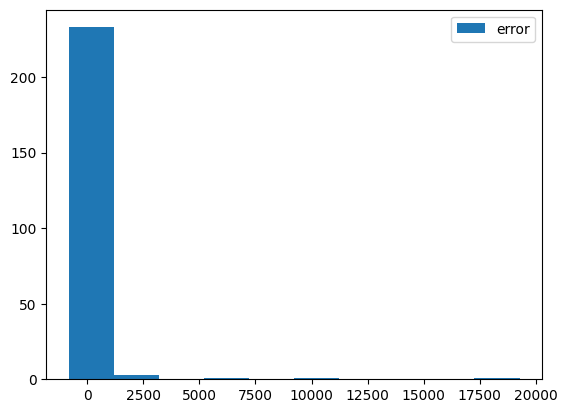

In [ ]:
errors3=(predics3-T3)/T3*100
plt.hist(errors3[:,0])
plt.legend(['error'])
plt.show()

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T3[:,0], y=predics3[:,0], mode='markers', marker_size=4, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T3[:,0], y=T3[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T3[:,0], y=errors3[:,0], mode='markers', marker_size=4, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-10, 10], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

## mesh

In [ ]:
x_mesh, y_mesh = np.linspace(0, 100, 31), np.linspace(20, 150, 31)
# x_mesh, y_mesh = np.arange(-1, 2, 0.1), np.arange(-1, 2, 0.1)
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
x_mesh = x_mesh.flatten().reshape(31*31,1)
y_mesh = y_mesh.flatten().reshape(31*31,1)
mesh3=np.concatenate((x_mesh, y_mesh), axis=1)
x_mesh[:5]

array([[ 0.        ],
       [ 3.33333333],
       [ 6.66666667],
       [10.        ],
       [13.33333333]])

In [ ]:
mesh_predics3=scaler_T3.inverse_transform(  bp3.run( scaler_X3.transform(mesh3) )  )

## plot

In [ ]:
fig_predic=go.Figure()
fig_predic.add_trace(go.Scatter3d(x=data3[:,0], y=data3[:,1], z=data3[:,2], mode='markers', marker_size=6, name='data'))
fig_predic.add_trace(go.Scatter3d(x=data3[:,0], y=data3[:,1], z=predics3[:,0], mode='markers', marker_size=6, name='predics'))
fig_predic.add_trace(go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics3[:,0], mode='markers', marker_size=2, name='mesh-predics', visible='legendonly'))

fig_predic.update_layout(
    scene = {
        "xaxis": {"range":[0,100], "nticks": 20},
        "yaxis": {"range":[20,150], "nticks": 20},
        # "zaxis": {"range":[1.1,1.5], "nticks": 6},
        'xaxis_title': '%H3PO4',
        'yaxis_title': 'Temperature, C',
        'zaxis_title': 'Pressure, mbar',
        'camera_eye': {"x": 1.5, "y": -1.5, "z": .7},
        "aspectratio": {"x": 1, "y": 1, "z": 0.6},
        'camera_center': {"x": 0, "y": 0, "z": -0.01}
    },
    width=1000, height=1000,
    margin=dict(l=30, r=30, b=30, t=30),
    title_text=' ',
    title_x=0.5,
)
fig_predic.update_scenes(camera_projection_type="orthographic")
# fig_predic.write_html("Na,K..H2PO4,SO4 density ortho 170522.html")

fig_predic.show()

In [ ]:
bp3.print_weights()

Layers (input, hidden, output):  [2, 4, 1] sigmoid linear
Hidden layer weights:  [[0.807284628292032, -2.529482016255705, 1.6353084608789454, 2.548967112384344], [-2.2278329733045674, -0.2852300972735734, 2.2181283348768397, -0.8321259264011612]]
Hidden layer biases:  [[3.357216785926395, -1.817122738265093, -6.368237983036172, 0.46260097605455747]]
Outlet layer weights:  [[-6.20677316410875], [-1.795114906436459], [-4.874143431009054], [-1.8255413731287133]]
Outlet layer biases:  [[7.243595471079233]]


In [ ]:
bp3.export_weights_as_pandas()

,0,1,2,3
0,0.807285,-2.529482,1.635308,2.548967
1,-2.227833,-0.285230,2.218128,-0.832126
0,3.357217,-1.817123,-6.368238,0.462601
0,-6.206773,NaN,NaN,NaN
1,-1.795115,NaN,NaN,NaN
2,-4.874143,NaN,NaN,NaN
3,-1.825541,NaN,NaN,NaN
0,7.243595,NaN,NaN,NaN


In [ ]:
print_scaler_data(scaler_data3)

scaler X -- mean, stdev:   [54.0167364  73.13807531] [30.67537774 34.91450667]
scaler T -- mean, stdev:   [305.48522594] [375.99549062]


# f(x1,x2,x3)  3-6-3

## data

In [ ]:
data5=pd.DataFrame([[3.5432, 44.1176470588235, 39.7307914468193, 1.7787,
        17.1987641606591, 1.03129605623734, 'exp1'],
       [3.5432, 44.1176470588235, 46.7421075844933, 1.61172,
        14.2121524201854, 1.33418381984987, 'exp1'],
       [3.5432, 44.1176470588235, 53.7534237221673, 1.43143,
        11.6947472745292, 1.78559851572739, 'exp1'],
       [3.5432, 44.1176470588235, 60.7647398598413, 1.3224,
        9.75359342915811, 1.8067259420946, 'exp1'],
       [3.61182, 52.5, 33.2044509861419, 1.73556, 26.109391124871,
        1.2784366054216, 'exp2'],
       [3.61182, 52.5, 39.0640599836963, 1.50787, 23.0448383733055,
        1.30063890921072, 'exp2'],
       [3.61182, 52.5, 44.9236689812508, 1.28216, 18.3303085299456,
        1.6396367983226, 'exp2'],
       [3.61182, 52.5, 50.7832779788052, 1.15506, 15.3439153439153,
        1.6793895639359, 'exp2'],
       [3.546, 41.9753086419753, 48.1611135844767, 1.548,
        13.5922330097087, 1.58024190679573, 'exp4'],
       [3.546, 41.9753086419753, 48.1611135844767, 1.548,
        13.5922330097087, 1.58024190679573, 'exp4'],
       [3.546, 41.9753086419753, 55.3852806221482, 1.44056,
        11.2244897959184, 1.75311864093404, 'exp4'],
       [3.546, 41.9753086419753, 62.6094476598198, 1.37192,
        9.61538461538462, 2.33968055882646, 'exp4'],
       [3.15645, 37.3333333333333, 46.223478589122, 1.62281,
        13.6842105263158, 1.26494899078895, 'exp7'],
       [3.15645, 37.3333333333333, 54.3805630460259, 1.48603,
        11.340206185567, 1.53596150580697, 'exp7'],
       [3.15645, 37.3333333333333, 62.5376475029298, 1.39922,
        9.18367346938775, 2.0761800720865, 'exp7'],
       [3.15645, 37.3333333333333, 70.6947319598337, 1.3311,
        7.54716981132076, 2.46615102122547, 'exp7'],
       [3.21264, 48.4375, 35.9576897475555, 1.424, 20.0,
        0.877430345937249, 'exp8'],
       [3.21264, 48.4375, 42.3031644088888, 1.25664, 17.3469387755102,
        1.21143181315366, 'exp8'],
       [3.21264, 48.4375, 48.6486390702222, 1.1736, 14.8514851485148,
        1.51090731456155, 'exp8'],
       [3.21264, 48.4375, 54.9941137315555, 1.0787, 12.8712871287129,
        2.10993639581657, 'exp8'],
       [3.17988, 57.7039274924471, 29.8573774179341, 1.2664,
        28.2178217821782, 0.922752144650929, 'exp9'],
       [3.17988, 57.7039274924471, 35.1263263740401, 1.0569,
        24.3731193580742, 1.1326227604219, 'exp9'],
       [3.17988, 57.7039274924471, 40.3952753301461, 0.9309,
        20.4901960784314, 1.2410533380211, 'exp9'],
       [3.17988, 57.7039274924471, 45.6642242862522, 0.87596,
        18.034188034188, 1.58738143967855, 'exp9']],columns=['SO4_in', 'FA_in', 'DCP_in',	'SO4', 'FA', 'P2O5_norm',	'exp'])

In [ ]:
# data5=pd.read_csv('new_dcp_data.csv')
data5.iloc[:,[0,1,2,3,4,5,6]]

,SO4_in,FA_in,DCP_in,SO4,FA,P2O5_norm,exp
0,3.54320,44.117647,39.730791,1.77870,17.198764,1.031296,exp1
1,3.54320,44.117647,46.742108,1.61172,14.212152,1.334184,exp1
2,3.54320,44.117647,53.753424,1.43143,11.694747,1.785599,exp1
3,3.54320,44.117647,60.764740,1.32240,9.753593,1.806726,exp1
4,3.61182,52.500000,33.204451,1.73556,26.109391,1.278437,exp2
5,3.61182,52.500000,39.064060,1.50787,23.044838,1.300639,exp2
6,3.61182,52.500000,44.923669,1.28216,18.330309,1.639637,exp2
7,3.61182,52.500000,50.783278,1.15506,15.343915,1.679390,exp2
8,3.54600,41.975309,48.161114,1.54800,13.592233,1.580242,exp4
9,3.54600,41.975309,48.161114,1.54800,13.592233,1.580242,exp4


In [ ]:
X5=np.array(data5)[:,[0,1,2]]
T5=np.array(data5)[:,[3,4,5]]

## scaling

In [ ]:
scaler_X5 = preprocessing.StandardScaler().fit(X5)
scaler_T5 = preprocessing.StandardScaler().fit(T5)

# scaler_X5.mean_, scaler_X5.scale_ = np.zeros(X5.shape[1]), np.ones(X5.shape[1]) # disable scaling
# scaler_T5.mean_, scaler_T5.scale_ = np.zeros(T5.shape[1]), np.ones(T5.shape[1]) # disable scaling

scaler_data5 = [scaler_X5.mean_, scaler_X5.scale_, scaler_T5.mean_, scaler_T5.scale_]
print('scaler X -- mean, stdev:  ',scaler_data5[0], scaler_data5[1])
print('scaler T -- mean, stdev:  ',scaler_data5[2], scaler_data5[3])

X_sc5 = scaler_X5.transform(X5)
T_sc5 = scaler_T5.transform(T5)
X_sc5[0:3]

scaler X -- mean, stdev:   [ 3.37499833 47.01128609 47.91944614] [ 0.19399856  6.75635049 10.01060258]
scaler T -- mean, stdev:   [ 1.35981833 15.90218114  1.5435811 ] [0.22990127 5.44826372 0.40863675]


array([[ 0.86702535, -0.42828433, -0.81799818],
       [ 0.86702535, -0.42828433, -0.11760916],
       [ 0.86702535, -0.42828433,  0.58277986]])

## parameter searching

In [ ]:
bp_iter=VectorBackProp(layers=[3,6,3], hidden_activation = 'prelu')
learning_rate = [0.001, 0.005, 0.01]
momentum_term = [0.8, 0.9, 0.95]
learning_rate_decay = [0]
repeats = range(10)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc5, T_sc5, epochs=1000, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], bp_iter.loss_list[-2] - bp_iter.loss_list[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                if i%25==0 and i>0:
                    print ('\n')
                i+=1

total runs: 90
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 

26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 

76 77 78 79 80 81 82 83 84 85 86 87 88 89 

In [ ]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'final_loss_gradient'])
output_table.fillna(value = 1.1, inplace = True)
output_table.head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,final_loss_gradient
0,0.001,0.8,0.0,0.069325,0.000013
1,0.001,0.8,0.0,0.083030,0.000009
2,0.001,0.8,0.0,0.075350,0.000023
3,0.001,0.8,0.0,0.087602,0.000003
4,0.001,0.8,0.0,0.082579,0.000027


In [ ]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.2],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'final_loss_gradient', values = output_table['final_loss_gradient']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'grey',
    paper_bgcolor = 'beige'
)

fig.show()

## running best parameters

In [ ]:
bp_iter=VectorBackProp(layers=[3,6,3], hidden_activation = 'prelu')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X_sc5, T_sc5, epochs=1000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 0., repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [ ]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.1])
fig2.show()

## best_weights_for_now

In [ ]:
best_weights_for_now5=weights_lists2[11]
best_weights_for_now5

[[[0.3221010176399555,
   0.5962493541666265,
   0.5159566833208289,
   -0.27924018093961006,
   -0.5067537840517788,
   0.06264381535044124],
  [-0.23507620937113965,
   -0.7005277519122326,
   0.3292612436236648,
   0.27119907745134986,
   1.4155053175188839,
   0.23264471330925146],
  [-0.023614115849085834,
   -0.604579347190869,
   -0.9844632674470162,
   1.7993588299043013,
   -0.1802114132739458,
   -1.5899722397207061]],
 [[-0.7046130676607527,
   1.573823721646079,
   -0.8755602303243817,
   -0.9430790083436896,
   1.1204000063612576,
   0.9699500022497339]],
 [[0.1973168764375683, -0.06633218196157292, 0.4719114619872503],
  [-0.48068678130439196, 0.026132273543574558, 1.09417833070012],
  [0.6551094731672061, 0.6622089082798385, 0.6416459066072158],
  [-0.4064434867993746, -0.2389690817152107, 1.1331857663090885],
  [-1.286797872092987, 0.18433294112914733, 1.017997362738303],
  [0.83706789879655, 0.40061277076830887, -1.3368866710205538]],
 [[1.3341883254958866, -0.84743379

In [ ]:
manual_best_weights_for_now5=[[[0.8535201744981578,
   0.23891613325375433,
   -0.3706213592894098,
   -0.4319215564257858,
   0.5806683166099315,
   -0.45312440005788335],
  [-1.3954718784061861,
   -0.695150962232366,
   1.1092111487917213,
   0.5088073751345356,
   0.5475099337474189,
   0.9996855926675174],
  [0.2864841341539176,
   -0.9760182043221927,
   0.13147906109812887,
   1.176281755284305,
   -0.8627091456740976,
   -0.9969945042729156]],
 [[-1.7087073195023568,
   0.23484366855236094,
   0.904933268468465,
   -0.521738685225468,
   -0.7736711357904624,
   1.1694566633838352]],
 [[-0.37439150804139865, -0.12464629196196286, 2.250932496148333],
  [0.6951467932848032, 0.43765573963810295, -0.3777968880846245],
  [-1.089233486958558, 0.16654587440970814, 0.7755593752719424],
  [-0.16760703937947458, -0.34873049602012374, 1.087041365827288],
  [0.5250137257120451, 0.7309124150382786, 0.6503922051030756],
  [0.25020352808877644, 0.31343691683212843, -0.8403323706548815]],
 [[0.2889052934673156, -0.9086179498937622, 0.19248109225363927]]]

 # epochs=1000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 0.
 # loss = 0.0284

## fitting best parameters

In [ ]:
bp5=VectorBackProp(layers=[3,6,3], hidden_activation = 'prelu')

In [ ]:
# bp5.fit_graddescent(X_sc5, T_sc5, epochs=3000, eps=0.001, repeat=False)
# bp5.import_weights(best_weights_for_now5)
bp5.import_weights(manual_best_weights_for_now5)
bp5.fit(X_sc5, T_sc5, epochs=10000, learning_rate = 0.01, momentum_term = 0.9, learning_rate_decay = 1., repeat=True)

In [ ]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp5.loss_list[20:], name=''))
print('Initial loss =', bp5.loss_list[0])
print('Final loss =', bp5.loss_list[-1])
fig1.show()

Initial loss = 0.028382879846776662
Final loss = 0.028332913247589218


## prediction

In [ ]:
predics5=scaler_T5.inverse_transform(bp5.run(X_sc5))
predics5

array([[ 1.76312938, 17.41844692,  1.03526098],
       [ 1.56641473, 13.88102083,  1.35765046],
       [ 1.40697973, 11.5291594 ,  1.65393958],
       [ 1.34080709, 10.44312998,  1.8861871 ],
       [ 1.72474082, 26.84907641,  1.21347743],
       [ 1.51962687, 22.5469824 ,  1.393421  ],
       [ 1.31451293, 18.24488838,  1.57336458],
       [ 1.15982684, 14.69654058,  1.70471165],
       [ 1.56858714, 13.14151085,  1.5581039 ],
       [ 1.56858714, 13.14151085,  1.5581039 ],
       [ 1.43818505, 11.31210133,  1.85873091],
       [ 1.36505542,  9.75083964,  2.28497975],
       [ 1.63012994, 14.35783935,  1.3023633 ],
       [ 1.47885926, 11.74146984,  1.56925502],
       [ 1.38857884,  9.12306897,  2.04622571],
       [ 1.34286875,  7.33095221,  2.48299508],
       [ 1.44146255, 19.68740573,  0.85095804],
       [ 1.2851706 , 17.20457264,  1.19052034],
       [ 1.15653987, 15.08936461,  1.51752065],
       [ 1.07030573, 12.66875284,  2.09249308],
       [ 1.2483389 , 27.84728955,  0.964

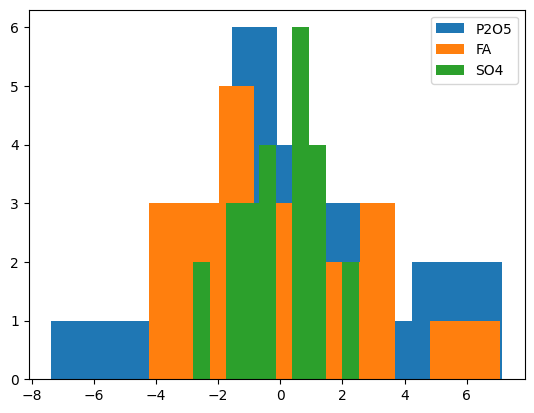

In [ ]:
pred=predics5
predics5_y1_vbp=pred[:,0]
error5_y1_vbp=(predics5_y1_vbp-T5[:,0])/T5[:,0]*100
predics5_y2_vbp=pred[:,1]
error5_y2_vbp=(predics5_y2_vbp-T5[:,1])/T5[:,1]*100
predics5_y3_vbp=pred[:,2]
error5_y3_vbp=(predics5_y3_vbp-T5[:,2])/T5[:,2]*100

plt.hist(error5_y3_vbp)
plt.hist(error5_y2_vbp)
plt.hist(error5_y1_vbp)
plt.legend(['P2O5', 'FA', 'SO4'])
plt.show()

In [ ]:
fig = make_subplots(rows=1, cols=3, subplot_titles=("SO4", "FA", "P2O5"), column_widths=[0.33, 0.33, 0.33],
                     specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]])

fig.add_trace(go.Scatter(x=T5[:,0] , y=predics5_y1_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics SO4', marker_color='black' ), 1, 1)
fig.add_trace(go.Scatter(x=T5[:,1] , y=predics5_y2_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics FA', marker_color='black' ), 1, 2)
fig.add_trace(go.Scatter(x=T5[:,2] , y=predics5_y3_vbp, mode='markers', marker_size=4, text=data5.exp, name='predics P2O5', marker_color='black' ), 1, 3)

fig.add_trace(go.Scatter(x=T5[:,0] , y=error5_y1_vbp, mode='markers', marker_size=4, text=data5.exp, name='error SO4', marker_color='orange' ), 1, 1, secondary_y=True,)
fig.add_trace(go.Scatter(x=T5[:,1] , y=error5_y2_vbp, mode='markers', marker_size=4, text=data5.exp, name='error FA', marker_color='orange' ), 1, 2, secondary_y=True,)
fig.add_trace(go.Scatter(x=T5[:,2] , y=error5_y3_vbp, mode='markers', marker_size=4, text=data5.exp, name='error P2O5', marker_color='orange' ), 1, 3, secondary_y=True,)

fig.update_layout(title='', autosize=True,
                  width=1550, height=400,
                  margin=dict(l=0, r=0, b=0, t=30))

fig.update_xaxes(title_text="", range=[0.5, 2], row=1, col=1)
fig.update_yaxes(title_text="", range=[0.5, 2], row=1, col=1)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=1, secondary_y=True, showgrid=False, tick0=-10, dtick=2)

fig.update_xaxes(title_text="", range=[0, 30], row=1, col=2)
fig.update_yaxes(title_text="", range=[0, 30], row=1, col=2)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=2, secondary_y=True, showgrid=False, tickvals=[-10,-5,-1,0,1,5,10])

fig.update_xaxes(title_text="", range=[0.5, 2], row=1, col=3)
fig.update_yaxes(title_text="", range=[0.5, 2], row=1, col=3)
fig.update_yaxes(title_text="%error", range=[-10, 10], row=1, col=3, secondary_y=True, showgrid=False, tick0=-10, dtick=2)

fig.show()

In [ ]:
bp5.export_weights_as_pandas()

,0,1,2,3,4,5
0,0.853144,0.238942,-0.372561,-0.433294,0.580311,-0.455630
1,-1.395156,-0.695365,1.112327,0.507098,0.548502,1.004759
2,0.288903,-0.975012,0.132179,1.175798,-0.861742,-0.990940
0,-1.709658,0.236085,0.907535,-0.520639,-0.773799,1.174458
0,-0.372478,-0.127210,2.251795,NaN,NaN,NaN
1,0.694693,0.438158,-0.376645,NaN,NaN,NaN
2,-1.089216,0.162082,0.785024,NaN,NaN,NaN
3,-0.166791,-0.347998,1.086050,NaN,NaN,NaN
4,0.524726,0.731897,0.648902,NaN,NaN,NaN
5,0.252713,0.314919,-0.846228,NaN,NaN,NaN


# 3-2-1 with confidence

## data

In [ ]:
data=CopyPasteToArray('''
Sample	MgCl2	NaCl	Solvent	T	Confidences
60-1	74.4	10.1	67.3	60	0
60-2	75.8	8.80	67.1	60	0
60-3	76.8	7.56	66.4	60	0
60-t	77.5	5.80	65.5	60	1
60-4	81.8	5.05	66.5	60	0.1
60-5	88.0	4.20	68.1	60	5
60-6	92.8	2.47	68.0	60	5
60-7	97.5	1.21	66.5	60	5
Na_Mg-60	70	30	73.3	60	1
Na_Mg-60	75	25	73.0	60	1
Na_Mg-60	80	20	72.5	60	1
Na_Mg-60	85	15	71.3	60	1
Na_Mg-60	90	10	69.3	60	1
Na_Mg-60	95	5	66.1	60	1
80-1	73.0	9.44	67.7	80	1
80-2	73.8	8.23	66.0	80	1
80-3	74.5	7.22	65.0	80	1
80-t	75.5	5.70	63.4	80	1
80-5	77.3	5.69	64.1	80	1
80-6	79.7	4.90	65.5	80	1
80-6b	81.3	4.57	65.7	80	1
80-7	85.1	4.30	66.3	80	1
80-7b	87.2	3.60	65.7	80	1
80-8	91.7	2.97	65.6	80	1
80-9	93.5	2.40	65.2	80	1
Na_Mg-80	70	30	72.6	80	1
Na_Mg-80	75	25	72.3	80	1
Na_Mg-80	80	20	71.6	80	1
Na_Mg-80	85	15	70.2	80	1
Na_Mg-80	90	10	67.9	80	1
Na_Mg-80	95	5	64.4	80	1
''')
# data
np_data=np.array(data)
data_cols=pd.DataFrame(np_data[1:,1:6], dtype=float)
text_cols1=pd.DataFrame(np_data[1:,0])
# text_cols2=pd.DataFrame(np_data[1:,4])
df_satur3=pd.concat([
                    text_cols1,
                    data_cols,
                    # text_cols2
                    ], axis=1)
df_satur3.columns=np_data[0]
df_satur3.head(3)

,Sample,MgCl2,NaCl,Solvent,T,Confidences
0,60-1,74.4,10.10,67.3,60.0,0.0
1,60-2,75.8,8.80,67.1,60.0,0.0
2,60-3,76.8,7.56,66.4,60.0,0.0


In [ ]:
n=14
df=df_satur3.copy()
Satur60_3=go.Scatter3d(x=df.MgCl2[0:n], y=df.NaCl[0:n], z=df.Solvent[0:n], text=df.Sample[0:n], name='Saturation 60C tests', mode='markers', marker_color='tan', marker_size=4, opacity = 0.8)
Satur80_3=go.Scatter3d(x=df.MgCl2[n:], y=df.NaCl[n:], z=df.Solvent[n:], text=df.Sample[n:], name='Saturation 80C tests', mode='markers', marker_color='brown', marker_size=4, opacity = 0.8)

In [ ]:
fig = go.Figure()

fig.add_trace(Satur60_3)
fig.add_trace(Satur80_3)

fig.update_layout(
        scene = {
            'camera_eye': {"x": 0., "y": -0.01, "z": 1.5},
            "aspectratio": {"x": 1, "y": 1, "z": 2},
            'camera_center': {"x": 0, "y": 0, "z": -0.1},
            'xaxis': {'range': [0, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'yaxis': {'range': [0, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'zaxis': {'range': [0, 100], 'dtick': 10, 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
        },
        width=900, height=900,
        margin=dict(l=0, r=0, b=0, t=0),
        legend_y=0.9,
)
fig.update_scenes(camera_projection_type="orthographic")

# fig.write_html("DSW Experiment Iso 60C 061024.html")
fig.show()

In [ ]:
df_satur3.head()

,Sample,MgCl2,NaCl,Solvent,T,Confidences
0,60-1,74.4,10.10,67.3,60.0,0.0
1,60-2,75.8,8.80,67.1,60.0,0.0
2,60-3,76.8,7.56,66.4,60.0,0.0
3,60-t,77.5,5.80,65.5,60.0,1.0
4,60-4,81.8,5.05,66.5,60.0,0.1


In [ ]:
X1=np.array(df_satur3)[:,[1,2,4]]
T1=np.array(df_satur3)[:,[3]]
# conf1=np.ones_like(T1)
conf1=np.array(df_satur3)[:,[5]]

## scaling

In [ ]:
scaler_X1 = preprocessing.StandardScaler().fit(X1)
scaler_T1 = preprocessing.StandardScaler().fit(T1)

# scaler_X1.mean_, scaler_X1.scale_ = 0, 1 # disable scaling
# scaler_T1.mean_, scaler_T1.scale_ = 0, 1 # disable scaling

scaler_data1 = [scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_]
print('scaler X -- mean, stdev:  ',scaler_data1[0], scaler_data1[1])
print('scaler T -- mean, stdev:  ',scaler_data1[2], scaler_data1[3])

X_sc1 = scaler_X1.transform(X1)
T_sc1 = scaler_T1.transform(T1)
X_sc1[0:3]

scaler X -- mean, stdev:   [82.16774194 10.13580645 70.96774194] [7.93348913 8.13385231 9.95306363]
scaler T -- mean, stdev:   [67.74516129] [2.86995995]


array([[-0.97910791, -0.00440215, -1.10194633],
       [-0.80264078, -0.16422802, -1.10194633],
       [-0.67659284, -0.31667731, -1.10194633]])

## parameter searching

In [ ]:
bp_iter=VectorBackProp(layers=[3,2,1], hidden_activation = 'sigmoid')
learning_rate = [0.01, 0.05, .1]
momentum_term = [0.90, 0.95, 0.97]
learning_rate_decay = [0]
repeats = range(5)
rows=len(learning_rate) * len(momentum_term) * len(learning_rate_decay) * len(repeats)
print ('total runs:', rows)
output = np.zeros((rows,5))
i=0
weights_list = []
for lr in learning_rate:
    for mt in momentum_term:
        for lrd in learning_rate_decay:
            for rep in repeats:
                bp_iter.fit(X_sc1, T_sc1, epochs=1000, confidences=conf1, learning_rate = lr, momentum_term = mt, learning_rate_decay = lrd, repeat=False)
                relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
                output[i] = [lr, mt, lrd, bp_iter.loss_list[-1], relative_delta[-1]]
                weights_list.append(bp_iter.export_weights())
                print (i, end=' ')
                i+=1


total runs: 45
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 

/content/MLNN.py:37: RuntimeWarning:

overflow encountered in exp

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning:

overflow encountered in reduce

/content/MLNN.py:97: RuntimeWarning:

overflow encountered in multiply

/content/MLNN.py:93: RuntimeWarning:

overflow encountered in square

/content/MLNN.py:97: RuntimeWarning:

invalid value encountered in multiply

/content/MLNN.py:125: RuntimeWarning:

overflow encountered in matmul

/content/MLNN.py:125: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-667540624.py:16: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipython-input-667540624.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



35 36 37 38 39 40 41 42 43 44 

In [ ]:
output_table = pd.DataFrame(data=output, columns=['learning_rate', 'momentum_term', 'learning_rate_decay', 'final_loss', 'relative_delta'])
output_table.fillna(value = 1.1, inplace = True)
output_table.sort_values('final_loss').head()

,learning_rate,momentum_term,learning_rate_decay,final_loss,relative_delta
22,0.05,0.95,0.0,0.069762,-0.003770
18,0.05,0.90,0.0,0.073887,-0.003326
21,0.05,0.95,0.0,0.074736,-0.000261
12,0.01,0.97,0.0,0.075009,-0.011677
6,0.01,0.95,0.0,0.076636,-0.004878


In [ ]:
fig = go.Figure(data=
    go.Parcoords(

        dimensions = list([
            dict(
                label = 'learning_rate', values = output_table['learning_rate']),
            dict(
                label = 'momentum_term', values = output_table['momentum_term']),
            dict(range = [0, 1],
                label = 'learning_rate_decay', values = output_table['learning_rate_decay']),
            dict(range = [0, 0.05],
                label = 'final_loss', values = output_table['final_loss']),
            dict(
                label = 'relative_delta', values = output_table['relative_delta']),
        ])
    )
)

fig.update_layout(
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.show()

## running best parameters

In [ ]:
bp_iter=VectorBackProp(layers=[3,2,1], hidden_activation = 'sigmoid')
weights_lists2=[]
loss_lists2=[]
relative_delta_lists2=[]
n = 20
for i in range(n):
    bp_iter.fit(X_sc1, T_sc1, epochs=2000, confidences=conf1, learning_rate = 0.005, momentum_term = 0.95, learning_rate_decay = 0, repeat=False)
    relative_delta=[(a-b)/a*100 for a,b in zip(bp_iter.loss_list,[0]+bp_iter.loss_list[:-1])]
    weights_lists2.append(bp_iter.export_weights())
    loss_lists2.append(bp_iter.loss_list)
    relative_delta_lists2.append(relative_delta)

In [ ]:
fig2=go.Figure()
[fig2.add_trace(go.Scatter(y=loss_lists2[i][100:], name=i)) for i in range(n)]
fig2.update_layout (yaxis_range=[0,0.05], title='Loss')
fig2.show()

## best_weights_for_now

In [ ]:
# best_weights_for_now1=weights_list[14]  # list from parameter searching

In [ ]:
best_weights_for_now1=weights_lists2[17]
best_weights_for_now1

[[[-2.8625508532165673, 0.461869815404821],
  [2.8808733586230257, 5.506953431075671],
  [-6.444626564702507, 0.9990055478543239]],
 [[1.8282434408419668, -0.9345436338498354]],
 [[0.9784155672742668], [1.7413681946824506]],
 [[-0.9668930248067132]]]

In [ ]:
manual_best_weights_for_now1=[[[0.5859013836185065, -2.427467086177052],
  [-0.358692128560213, -3.944716641580931],
  [0.3306991439712676, -0.20003285128791684]],
 [[-1.2766725986641019, -3.676814823608575]],
 [[-5.359421698190241], [-4.216632659134087]],
 [[2.1127433032050575]]]

 # 2 sigmoids
 # epochs=1000, learning_rate = 0.005, momentum_term = 0.95, learning_rate_decay = 0
 # loss = .031

## fitting best parameters

In [ ]:
bp1=VectorBackProp(layers=[3,2,1], hidden_activation = 'sigmoid')

In [ ]:
# bp1.import_weights(best_weights_for_now1)
bp1.import_weights(manual_best_weights_for_now1)
bp1.fit(X_sc1, T_sc1, epochs=2000, confidences=conf1, learning_rate = 0.005, momentum_term = 0.8, learning_rate_decay = 1, repeat=True)

In [ ]:
fig1=go.Figure()
fig1.add_trace(go.Scatter(y=bp1.loss_list[20:], name=''))
print('Initial loss =', bp1.loss_list[0])
print('Final loss =', bp1.loss_list[-1])
# fig1.show()

Initial loss = 0.03130375785750113
Final loss = 0.03130346286732567


## prediction

In [ ]:
predics1=scaler_T1.inverse_transform(bp1.run(X_sc1))
# predics1

In [ ]:
errors1=(predics1-T1)/T1*100
# plt.hist(errors1[:,0]) # division by 0

In [ ]:
marker_sizes = 4
marker_sizes = ((conf1[:,0] - conf1[:,0].min()) / (conf1[:,0].max() - conf1[:,0].min()) * (10-4) + 4).astype(float) # confidence

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=T1[:,0], y=predics1[:,0], mode='markers', marker_size=marker_sizes, name='predics', marker_color='black'),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=T1[:,0], mode='lines', line_color='red', line_width=0.2, showlegend=False),secondary_y=False)
fig.add_trace(go.Scatter(x=T1[:,0], y=errors1[:,0], mode='markers', marker_size=marker_sizes, name='errors', marker_color='orange'),secondary_y=True)

fig.update_xaxes(title_text="data")

# Set y-axes titles
fig.update_yaxes(title_text="predics", secondary_y=False)
fig.update_yaxes(title_text="% error", range=[-2, 2], secondary_y=True, showgrid=False, tick0=-5, dtick=2)

fig.show()

## mesh

In [ ]:
x_mesh, y_mesh, t_mesh = np.linspace(70, 96, 27), np.linspace(0, 40, 41), np.linspace(60, 80, 3)
x_mesh, y_mesh, t_mesh = np.meshgrid(x_mesh, y_mesh, t_mesh)
x_mesh = x_mesh.flatten().reshape(27*41*3,1)
y_mesh = y_mesh.flatten().reshape(27*41*3,1)
t_mesh = t_mesh.flatten().reshape(27*41*3,1)
mesh1=np.concatenate((x_mesh, y_mesh, t_mesh), axis=1)
x_mesh[:5]

array([[70.],
       [70.],
       [70.],
       [71.],
       [71.]])

**mesh filter**

In [ ]:
sum=x_mesh[:,0]+y_mesh[:,0]
sum<=100  # inside the triangle
x_mesh=x_mesh[sum<=100]
y_mesh=y_mesh[sum<=100]
t_mesh=t_mesh[sum<=100]
mesh1=np.concatenate((x_mesh, y_mesh, t_mesh), axis=1)
t_mesh[:5]

array([[60.],
       [70.],
       [80.],
       [60.],
       [70.]])

In [ ]:
mesh1 #x,y,T

array([[70.,  0., 60.],
       [70.,  0., 70.],
       [70.,  0., 80.],
       ...,
       [70., 30., 60.],
       [70., 30., 70.],
       [70., 30., 80.]])

**עד כאן**

In [ ]:
mesh_predics1=scaler_T1.inverse_transform(bp1.run(scaler_X1.transform(mesh1)))

In [ ]:
solub_surfaces=go.Scatter3d(x=x_mesh[:,0], y=y_mesh[:,0], z=mesh_predics1[:,0], mode='markers', text=t_mesh[:,0], marker_color='gray', marker_size=1, name='surface mesh-predics', visible=True)

In [ ]:
T=60  # סינון לפי טמפרטורה
solub_surface_60=go.Scatter3d(x=x_mesh[t_mesh[:,0]==T,0], y=y_mesh[t_mesh[:,0]==T,0], z=mesh_predics1[t_mesh[:,0]==T,0], mode='markers', text=t_mesh[t_mesh[:,0]==T,0], marker_color='tan', marker_size=1, name='surface mesh-predics 60C', visible=True)
T=80  # סינון לפי טמפרטורה
solub_surface_80=go.Scatter3d(x=x_mesh[t_mesh[:,0]==T,0], y=y_mesh[t_mesh[:,0]==T,0], z=mesh_predics1[t_mesh[:,0]==T,0], mode='markers', text=t_mesh[t_mesh[:,0]==T,0], marker_color='brown', marker_size=1, name='surface mesh-predics 80C', visible=True)

## Simulator results

In [ ]:
fig = go.Figure()

# fig.add_trace(Satur60)
# fig.add_trace(Satur80)
fig.add_trace(Satur60_3)
fig.add_trace(Satur80_3)
fig.add_trace(solub_surfaces)
fig.add_trace(solub_surface_60)
fig.add_trace(solub_surface_80)

fig.update_layout(
        scene = {
            'camera_eye': {"x": 0., "y": -0.01, "z": 1.5},
            "aspectratio": {"x": 1, "y": 1, "z": 1},
            'camera_center': {"x": 0, "y": 0, "z": -0.1},
            'xaxis': {'range': [70, 100], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'yaxis': {'range': [0, 30], 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
            'zaxis': {'range': [50, 75], 'dtick': 10, 'backgroundcolor': 'white', 'gridcolor': 'lightgrey'},
        },
        width=900, height=900,
        margin=dict(l=0, r=0, b=0, t=0),
        legend_y=0.9,
)
fig.update_scenes(camera_projection_type="orthographic")

# fig.write_html("DSW Solubility 181224.html")
fig.show()

## output

In [ ]:
bp1.print_weights()

Layers (input, hidden, output):  [3, 2, 1] sigmoid linear
Hidden layer weights:  [[0.5858551109137577, -2.4273911708107003], [-0.3586241087323709, -3.9446498508475965], [0.3306591322011618, -0.20001509965388792]]
Hidden layer biases:  [[-1.2768400626158392, -3.6767308448415617]]
Outlet layer weights:  [[-5.360354564757871], [-4.216709263961955]]
Outlet layer biases:  [[2.1128108131565213]]


In [ ]:
bp1.export_weights()

[[[0.5858551109137577, -2.4273911708107003],
  [-0.3586241087323709, -3.9446498508475965],
  [0.3306591322011618, -0.20001509965388792]],
 [[-1.2768400626158392, -3.6767308448415617]],
 [[-5.360354564757871], [-4.216709263961955]],
 [[2.1128108131565213]]]

In [ ]:
bp1.export_weights_as_pandas()

,0,1
0,0.585855,-2.427391
1,-0.358624,-3.944650
2,0.330659,-0.200015
0,-1.276840,-3.676731
0,-5.360355,NaN
1,-4.216709,NaN
0,2.112811,NaN


In [ ]:
print_scaler_data(scaler_data1)

scaler X -- mean, stdev:   [82.16774194 10.13580645 70.96774194] [7.93348913 8.13385231 9.95306363]
scaler T -- mean, stdev:   [67.74516129] [2.86995995]


In [ ]:
pd.DataFrame(scaler_data1)

,0,1,2
0,82.167742,10.135806,70.967742
1,7.933489,8.133852,9.953064
2,67.745161,NaN,NaN
3,2.869960,NaN,NaN


In [ ]:
scaler_T1.inverse_transform(bp1.run(scaler_X1.transform([[60,40,60],[70,24,80]])))

array([[73.65480134],
       [72.61459812]])

# Monosugars

In [ ]:
scaler_data = [[150.0, 1.7999999999999998, 110.0, 7.58125], [73.48469228349535, 0.4898979485566356, 8.660254037844387, 3.273801068712025], [35.86875], [8.451310456816742]]

scaler_X1 = preprocessing.StandardScaler().fit([[0,0,0,0]])
scaler_T1 = preprocessing.StandardScaler().fit([[0]])
scaler_X1.mean_, scaler_X1.scale_, scaler_T1.mean_, scaler_T1.scale_ = scaler_data

man_weights_list1=[[[1.4354005647645895,
   -0.9924296576113261,
   -1.0630561113481596,
   1.7194835956880752],
  [-4.55625349802236,
   -1.1592425503560146,
   -0.9535289444686097,
   -1.5068846789528747],
  [-1.8089303201758502,
   0.02655880669594385,
   -1.9088550645752123,
   -1.418194810011082],
  [-3.2473692897262953,
   0.355535696364372,
   0.9756313083412088,
   -0.5523277781659081]],
 [[-0.751513635252371,
   -1.489443273697562,
   3.135418245306132,
   -0.929230629050694]],
 [[3.192298350997745],
  [-3.1066789668928654],
  [3.4538237852823235],
  [-2.6875088327953764]],
 [[-2.6231233721404057]]]

#  4 sigmoid  rate 0.1 mom 0.95 loss 9E-15

In [ ]:
bp1=VectorBackProp(layers=[4,4,1], hidden_activation = 'sigmoid')
bp1.import_weights(man_weights_list1)

In [ ]:
Xmesh, Ymesh, Zmesh = np.mgrid[60:240:21j, 1.2:2.4:25j, 100:120:25j] #Time, HBr, T
values1=Xmesh.copy() # initial
for i in range(len(Xmesh)):
    for j in range(len(Xmesh[0])):
        for k in range(len(Xmesh[0,0])):
            values1[i,j,k]=scaler_T1.inverse_transform(bp1.run(scaler_X1.transform([[Xmesh[i,j,k],Ymesh[i,j,k],Zmesh[i,j,k],3.8]])))[0,0]

In [ ]:
fig = go.Figure()

values=values1
fig.add_trace(go.Isosurface(
    x=Xmesh.flatten(), # Time
    y=Ymesh.flatten(), # HBr
    z=Zmesh.flatten(), # T
    value=values.flatten(),
    isomin=20,
    isomax=60,
    surface_count=20,
    opacity=0.15,
    surface_fill=1,
    # colorscale=mycolorscale,
    # showscale=False,
    caps=dict(x_show=False, y_show=False, z_show=False),
    showlegend=True,
    ))
# fig.add_trace(go.Scatter3d(x=[sol1.x[0]], y=[sol1.x[1]], z=[sol1.x[2]], showlegend=False))
fig.update_layout(
        scene = dict(
                xaxis_title='Time, min',
                yaxis_title='HBr, gr',
                zaxis_title='T, C',
                ),
            # scene_camera_eye=dict(x=0, y=-2, z=0),
            width=1200,height=800,
            margin=dict(r=20, b=20, l=10, t=0),
            legend_y=.3,
            showlegend=True,
#             paper_bgcolor="LightGrey",
        )
fig.show()

# manual_sigmoid function

good for setting confidence array

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def manual_sigmoid(
    x: np.ndarray,
    x_mid: float,
    y_min: float,
    y_max: float,
    steepness: float = 1.0
) -> np.ndarray:
    """
    Generates y-values for a sigmoid-like curve based on input x-values.

    The curve is defined by a minimum and maximum y-value, and its inflection point
    (the center of the "S" shape) is explicitly set at `x_mid`.

    Args:
        x (np.ndarray): The array of input x-values for which to calculate y-values.
        x_mid (float): The x-value that corresponds to the inflection point of the
                       sigmoid curve. The y-value at this point will be (y_min + y_max) / 2.
        y_min (float): The lower asymptote (minimum value) of the sigmoid curve.
        y_max (float): The upper asymptote (maximum value) of the sigmoid curve.
        steepness (float, optional): A factor to control the sharpness of the curve.
                                     Values > 1.0 make it steeper. Defaults to 1.0.

    Returns:
        np.ndarray: The calculated y-values forming the sigmoid curve.

    Raises:
        ValueError: If x_mid is not within the range of the input x data.
    """
    # 1. Get x_min and x_max from the data itself
    x_min = np.min(x)
    x_max = np.max(x)

    # 2. Check that x_mid is within the valid range
    if not (x_min <= x_mid <= x_max):
        raise ValueError(f"x_mid ({x_mid}) must be between x_min ({x_min}) and x_max ({x_max}).")

    # 3. Normalize the x-values so that x_mid becomes the zero point.
    # This is a two-part linear scaling to map the range [x_min, x_max] to [-1, 1],
    # with the zero-crossing precisely at x_mid.
    x_normalized = np.zeros_like(x, dtype=float)

    # Handle values before the midpoint
    mask_before = x <= x_mid
    if x_mid > x_min:  # Avoid division by zero if x_mid is the same as x_min
        x_normalized[mask_before] = (x[mask_before] - x_mid) / (x_mid - x_min)

    # Handle values after the midpoint
    mask_after = x > x_mid
    if x_max > x_mid:  # Avoid division by zero if x_mid is the same as x_max
        x_normalized[mask_after] = (x[mask_after] - x_mid) / (x_max - x_mid)

    # 4. Create the sigmoid curve
    # The normalized range is now [-1, 1]. We scale it for the sigmoid function's input.
    # A multiplier of 6 maps this to a nice [-6, 6] range.
    sigmoid_input = x_normalized * 6 * steepness

    # The standard logistic function: 1 / (1 + e^-z)
    sigmoid_output = 1 / (1 + np.exp(-sigmoid_input))

    # 5. Scale the output [0, 1] to the desired y-range [y_min, y_max]
    y_calculated = y_min + sigmoid_output * (y_max - y_min)

    return y_calculated

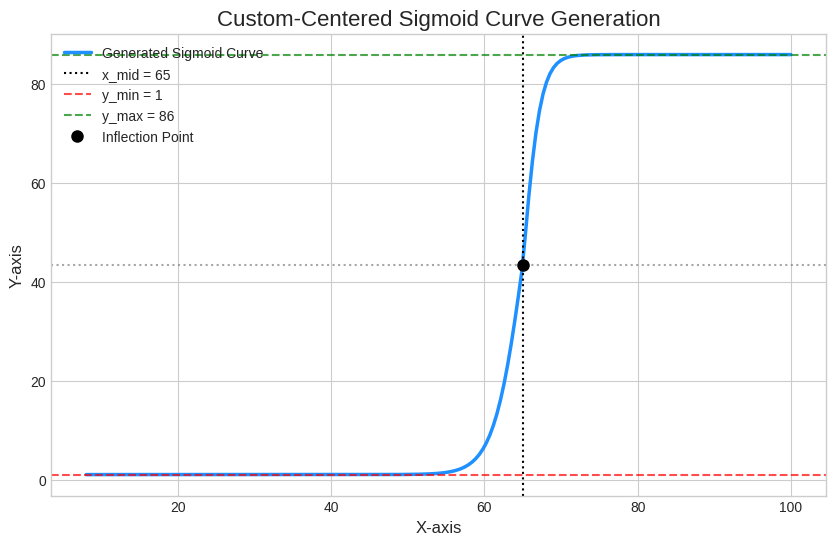

In [ ]:
# --- 1. Setup Parameters ---
# Define the range for our x-axis
x_values = np.linspace(8, 100, 200)

# Define the properties of our desired sigmoid curve
y_target_min = 1
y_target_max = 86
x_mid_point = 65  # The inflection point of the curve
steepness_factor = 5 # A slightly sharper curve

# --- 2. Generate the Sigmoid Data ---
# Use the function to calculate the y-values
y_sigmoid_values = manual_sigmoid(
    x=x_values,
    x_mid=x_mid_point,
    y_min=y_target_min,
    y_max=y_target_max,
    steepness=steepness_factor
)

# --- 3. Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the generated sigmoid curve
ax.plot(x_values, y_sigmoid_values, color='dodgerblue', linewidth=2.5, label='Generated Sigmoid Curve')

# Add visual aids to verify the function's behavior
ax.axvline(x=x_mid_point, color='k', linestyle=':', linewidth=1.5, label=f'x_mid = {x_mid_point}')
ax.axhline(y=y_target_min, color='r', linestyle='--', alpha=0.7, label=f'y_min = {y_target_min}')
ax.axhline(y=y_target_max, color='g', linestyle='--', alpha=0.7, label=f'y_max = {y_target_max}')
mid_y_val = (y_target_min + y_target_max) / 2
ax.axhline(y=mid_y_val, color='gray', linestyle=':', alpha=0.7)
ax.plot(x_mid_point, mid_y_val, 'ko', markersize=8, label='Inflection Point')


# Formatting
ax.set_title('Custom-Centered Sigmoid Curve Generation', fontsize=16)
ax.set_xlabel('X-axis', fontsize=12)
ax.set_ylabel('Y-axis', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True)
plt.show()

In [ ]:
conf_sigm = manual_sigmoid(
    x=X1[:,0],
    x_mid=80,
    y_min=0,
    y_max=10,
    steepness = 1.0)
conf_sigm

array([0.33569223, 0.74467945, 1.27861566, 1.82425524, 6.49568457,
       9.39508678, 9.87733869, 9.97527377, 0.02472623, 0.47425873,
       5.        , 8.47391335, 9.68585629, 9.94192942, 0.14774032,
       0.23660578, 0.35571189, 0.62973356, 1.6520487 , 4.55121108,
       6.09619785, 8.51772527, 9.2190898 , 9.82214541, 9.903258  ,
       0.02472623, 0.47425873, 5.        , 8.47391335, 9.68585629,
       9.94192942])